# Baseline Cross-Subject Motor Imagery Benchmark

## Project Context

This notebook implements the **baseline cross-subject experiment** for motor imagery classification. The goal is to measure how well a simple CSP + LDA pipeline generalizes to unseen subjects.

**Model:** CSP (Common Spatial Patterns) + LDA (Linear Discriminant Analysis)  
**Evaluation:** Cross-subject (train on all subjects except one, test on held-out subject)  
**Dataset:** BNCI2014_001 (9 subjects, 2 sessions, left vs right hand motor imagery)  

**Why this matters:**  
Cross-subject generalization is challenging in BCI because brain signals vary significantly across individuals. This baseline will help to identify which subjects are particularly difficult and motivate improvements in the next phase of the project.

# 1. Setup

## 1.1. Imports

In [ ]:
# Reproducible setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

# MOABB imports
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery
from moabb.evaluations import CrossSubjectEvaluation

# MNE for CSP
from mne.decoding import CSP

# scikit-learn imports
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# 2. Data

## 2.1. Dataset Setup

In [3]:
# Instantiate dataset and paradigm
dataset = BNCI2014_001()
paradigm = LeftRightImagery()

print("Dataset and paradigm initialized.")
print(f"Dataset: {dataset.__class__.__name__}")
print(f"Paradigm: {paradigm.__class__.__name__}")

Dataset and paradigm initialized.
Dataset: BNCI2014_001
Paradigm: LeftRightImagery


## 2.2. Dataset Metadata Inspection

In [4]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"Number of subjects: {len(dataset.subject_list)}")
print(f"Subject IDs: {dataset.subject_list}")
print(f"Number of sessions: {dataset.n_sessions}")
print(f"Event IDs (all classes): {dataset.event_id}")

DATASET INFORMATION
Number of subjects: 9
Subject IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of sessions: 2
Event IDs (all classes): {'left_hand': 1, 'right_hand': 2, 'feet': 3, 'tongue': 4}


In [5]:
print("\n" + "=" * 60)
print("PARADIGM INFORMATION")
print("=" * 60)

# Paradigm details
print(f"Frequency filters: {paradigm.filters}")
print(f"Paradigm events (left/right only): {paradigm.events}")


PARADIGM INFORMATION
Frequency filters: [[8, 32]]
Paradigm events (left/right only): ['left_hand', 'right_hand']


# 3. Baseline Pipeline

**CSP (Common Spatial Patterns):**  
A classic technique for motor imagery that learns spatial filters to maximize variance between classes.

**LDA (Linear Discriminant Analysis):**  
A simple linear classifier that works well with CSP features.

Use `n_components=8` for CSP, which extracts 4 spatial filters for each class (left and right). This is a common choice in motor imagery research that balances discriminability and generalization.

## 3.1. Pipeline Definition

In [6]:
# Build the baseline pipeline
# CSP extracts spatial patterns, LDA classifies in the transformed space
pipeline = make_pipeline(
    CSP(n_components=8, reg=None, log=True, norm_trace=False),
    LDA(solver='lsqr', shrinkage='auto')
)

# Create a dictionary for MOABB evaluation
pipelines = {'CSP+LDA': pipeline}

print("Baseline pipeline created:")
print(pipeline)

Baseline pipeline created:
Pipeline(steps=[('csp', CSP(log=True, n_components=8)),
                ('lineardiscriminantanalysis',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])


## 3.2. Cross-Subject Evaluation Setup

In [8]:
# Create cross-subject evaluation object
evaluation = CrossSubjectEvaluation(
    paradigm=paradigm,
    datasets=[dataset],
    overwrite=False
)

print("Cross-subject evaluation configured.")

Cross-subject evaluation configured.


## 3.2. Run Baseline Benchmark

In [ ]:
# Run the evaluation
print("Running cross-subject evaluation...")

results = evaluation.process(pipelines)

print("\nEvaluation complete!")
print(f"Results shape: {results.shape}")

Running cross-subject evaluation...
This may take a few minutes.


Evaluation complete!
Results shape: (18, 9)


## 3.4. Inspect Results

In [13]:
# Display first few rows
print(results)

print("\n" + "=" * 60)
print("Available columns:")
print("=" * 60)

       score      time  samples subject session  channels  n_sessions       dataset pipeline
0   0.910494  2.354805   2304.0       1  0train        22           2  BNCI2014-001  CSP+LDA
1   0.936535  2.354805   2304.0       1   1test        22           2  BNCI2014-001  CSP+LDA
2   0.570602  2.049957   2304.0       2  0train        22           2  BNCI2014-001  CSP+LDA
3   0.557870  2.049957   2304.0       2   1test        22           2  BNCI2014-001  CSP+LDA
4   0.983410  2.052011   2304.0       3  0train        22           2  BNCI2014-001  CSP+LDA
5   0.976852  2.052011   2304.0       3   1test        22           2  BNCI2014-001  CSP+LDA
6   0.750000  2.040626   2304.0       4  0train        22           2  BNCI2014-001  CSP+LDA
7   0.809221  2.040626   2304.0       4   1test        22           2  BNCI2014-001  CSP+LDA
8   0.508873  2.060064   2304.0       5  0train        22           2  BNCI2014-001  CSP+LDA
9   0.620563  2.060064   2304.0       5   1test        22           2 

In [15]:
# Summary statistics
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

print(f"Mean score: {results['score'].mean():.4f}")
print(f"Std score: {results['score'].std():.4f}")
print(f"Min score: {results['score'].min():.4f}")
print(f"Max score: {results['score'].max():.4f}")

RESULTS SUMMARY
Mean score: 0.7719
Std score: 0.1625
Min score: 0.5089
Max score: 0.9907


# 4. Per-Subject Analysis

## 4.1. Get Subject Performance

In [16]:
# Compute per-subject scores
per_subject_scores = results.groupby('subject')['score'].mean().sort_values()

print("=" * 60)
print("PER-SUBJECT PERFORMANCE (sorted from worst to best)")
print("=" * 60)
print(per_subject_scores)

print(f"\nBest performing subject: {per_subject_scores.idxmax()} ({per_subject_scores.max():.4f})")
print(f"Worst performing subject: {per_subject_scores.idxmin()} ({per_subject_scores.min():.4f})")

PER-SUBJECT PERFORMANCE (sorted from worst to best)
subject
2    0.564236
5    0.564718
6    0.666184
7    0.676697
4    0.779610
9    0.807292
1    0.923515
3    0.980131
8    0.984857
Name: score, dtype: float32

Best performing subject: 8 (0.9849)
Worst performing subject: 2 (0.5642)


## 4.2. Visualize Per-Subject Performance

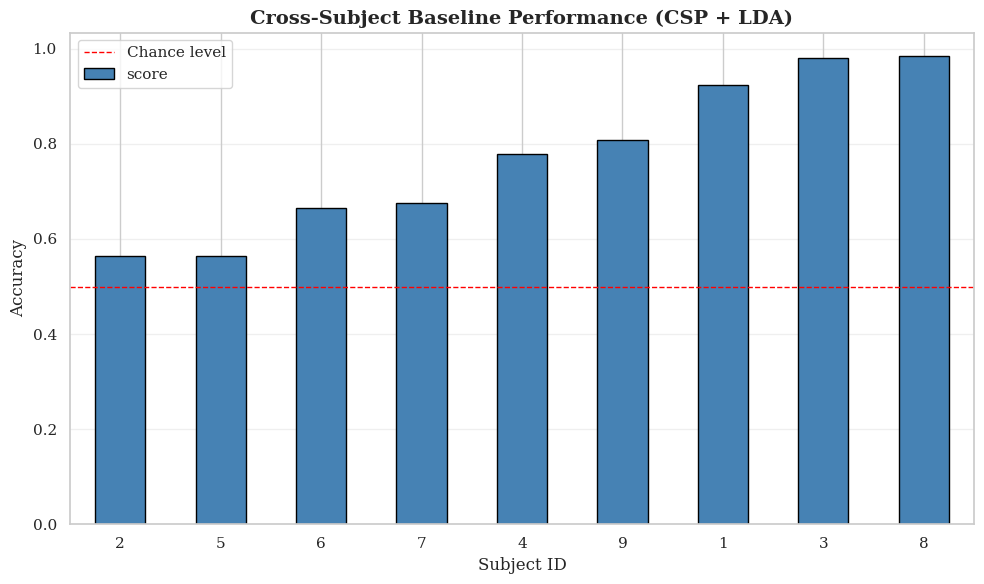

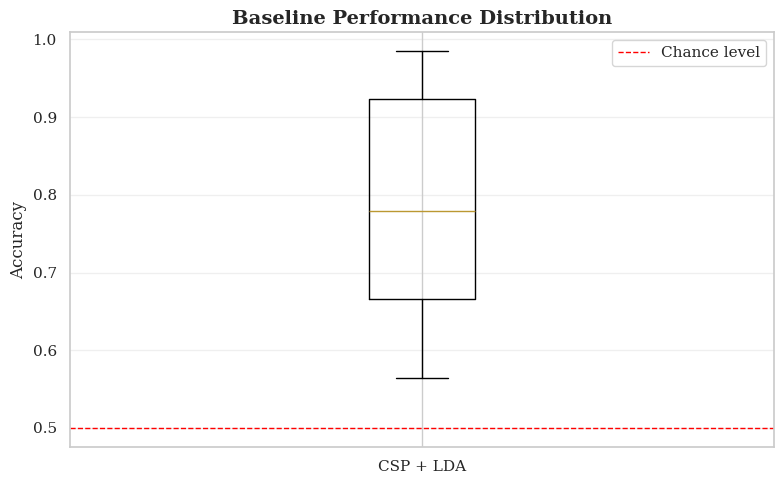

In [ ]:
plt.figure(figsize=(10, 6))
per_subject_scores.plot(kind='bar', color='steelblue', edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Subject Baseline Performance (CSP + LDA)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics plot
plt.figure(figsize=(8, 5))
plt.boxplot([per_subject_scores.values], labels=['CSP + LDA']) # type: ignore
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.ylabel('Accuracy', fontsize=12)
plt.title('Baseline Performance Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3. Identify Low-Performing Subjects

In [ ]:
# Rank subjects from worst to best
print("=" * 60)
print("LOW-PERFORMING SUBJECTS (candidates for improvement)")
print("=" * 60)

# Show bottom 3 subjects
bottom_subjects = per_subject_scores.head(3)
print("\nBottom 3 subjects:")
for subject, score in bottom_subjects.items(): # type: ignore
    print(f"  Subject {subject}: {score:.4f}")

# Compute how many subjects are below median
median_score = per_subject_scores.median()
below_median = (per_subject_scores < median_score).sum()

print(f"\nMedian score: {median_score:.4f}")
print(f"Subjects below median: {below_median}/{len(per_subject_scores)}")

print("\nThese subjects are primary candidates for improvement in the next phase.")

LOW-PERFORMING SUBJECTS (candidates for improvement)

Bottom 3 subjects:
  Subject 2: 0.5642
  Subject 5: 0.5647
  Subject 6: 0.6662

Median score: 0.7796
Subjects below median: 4/9

These subjects are primary candidates for improvement in the next phase.


## Interpretation and Next Steps

### What Was Learned

This baseline experiment reveals:

1. **Overall cross-subject performance:** The CSP + LDA pipeline achieves a certain level of generalization across subjects, but performance varies significantly.

2. **Subject variability:** Some subjects are much harder to classify than others when the model is trained on different subjects. This is expected in BCI research due to anatomical and functional differences across individuals.

3. **Room for improvement:** The variability in per-subject performance suggests that:
   - A subject-invariant approach may help (e.g., Riemannian geometry, domain adaptation)
   - Low-performing subjects could benefit from transfer learning or alignment techniques
   - The baseline serves as a reference point for future improvements

### Why This Motivates Improvement

Cross-subject BCI systems are important for practical applications where:
- We have limited calibration data from new users
- We want to leverage data from multiple subjects
- Quick setup without extensive training is needed

The baseline shows that a simple Euclidean approach (CSP + LDA) has limitations. The next phase will explore whether Riemannian geometry or alignment methods can improve generalization, especially for the most challenging subjects.